In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

loudness-0  loudness-1  loudness-2  bufmfcc_feats-0  \
p0  p1  p2  p3                                                         
0.0 0.0 0.0 0.0 -157.226593 -313.071198    0.000000     -1760.032118   
            0.1  -91.535083  -20.207500    0.004813     -1302.586912   
            0.2  -89.162975  -14.004900    0.009205     -1040.672131   
            0.3  -87.972090  -10.430750    0.013907     -1020.227748   
            0.4  -87.137594   -7.907103    0.018662     -1006.199840   
...                     ...         ...         ...              ...   
0.9 0.9 0.9 0.5   -7.773008   -6.126431    0.479745       121.899989   
            0.6   -5.483886   -3.750501    0.583238       112.347081   
            0.7   -4.665386   -3.144933    0.676383       144.902041   
            0.8   -3.115404   -1.915817    0.778028       140.581900   
            0.9   -2.043647   -0.778062    0.876170       145.964315   

                 bufmfcc_feats-1  bufmfcc_feats-2  bufmfcc_feats-4  \
p0  p1  p2  p3                                                       
0.0 0.0 0.0 0.0     1.263187e-14     2.400055e-13    -1.894781e-13   
            0.1     3.873773e+01     5.297085e+01     4.722949e+01   
            0.2     4.084790e+01     5.458989e+01     4.806328e+01   
            0.3     3.725687e+01     5.235849e+01     4.855623e+01   
            0.4     4.113363e+01     5.487504e+01     4.834742e+01   
...                          ...              ...              ...   
0.9 0.9 0.9 0.5    -2.579840e+01    -4.051147e+01     3.833931e+01   
            0.6    -3.063587e+01    -4.907305e+01     4.851548e+01   
            0.7    -3.080952e+01    -3.729052e+01     3.477153e+01   
            0.8    -2.913148e+01    -4.543553e+01     4.111991e+01   
            0.9    -3.023705e+01    -4.512981e+01     4.190272e+01   

                 bufmfcc_feats-5  bufmfcc_feats-6  bufmfcc_feats-7  ...  \
p0  p1  p2  p3                                                      ...   
0.0 0.0 0.0 0.0     2.526374e-14    -1.515825e-13     7.579123e-14  ...   
            0.1     4.780905e+01     4.310244e+01     4.415815e+01  ...   
            0.2     4.863813e+01     4.363743e+01     4.471496e+01  ...   
            0.3     4.921950e+01     4.502175e+01     4.594334e+01  ...   
            0.4     4.892083e+01     4.391823e+01     4.499342e+01  ...   
...                          ...              ...              ...  ...   
0.9 0.9 0.9 0.5    -1.660145e+01     9.844018e+00     2.435564e+00  ...   
            0.6    -2.056557e+01     1.715268e+01    -2.671696e-01  ...   
            0.7    -1.538800e+01     7.334871e+00     2.231686e+00  ...   
            0.8    -2.137955e+01     1.052847e+01    -3.129937e+00  ...   
            0.9    -1.938444e+01     1.343043e+01     9.384203e-02  ...   

                 bufmfcc_feats-11  bufmfcc_feats-12  bufmfcc_feats-13  \
p0  p1  p2  p3                                                          
0.0 0.0 0.0 0.0      1.010550e-13     -3.410605e-13          0.000000   
            0.1      3.677408e+01      3.509956e+01         39.084438   
            0.2      3.713416e+01      3.540424e+01         39.399608   
            0.3      3.937727e+01      3.908487e+01         41.663275   
            0.4      3.739886e+01      3.566443e+01         39.654870   
...                           ...               ...               ...   
0.9 0.9 0.9 0.5     -2.427357e+01     -1.612063e+01         -4.220084   
            0.6     -3.460333e+01     -2.121540e+01         -8.061736   
            0.7     -2.444708e+01     -1.624101e+01         -5.776864   
            0.8     -2.869281e+01     -1.972423e+01         -9.817114   
            0.9     -3.047355e+01     -1.852530e+01         -7.098832   

                  spectral-0   spectral-1    spectral-2   spectral-3  \
p0  p1  p2  p3                                                         
0.0 0.0 0.0 0.0  9800.000000  5669.094184  2.369119e-16     1.599992   
            0.1  1404.93387

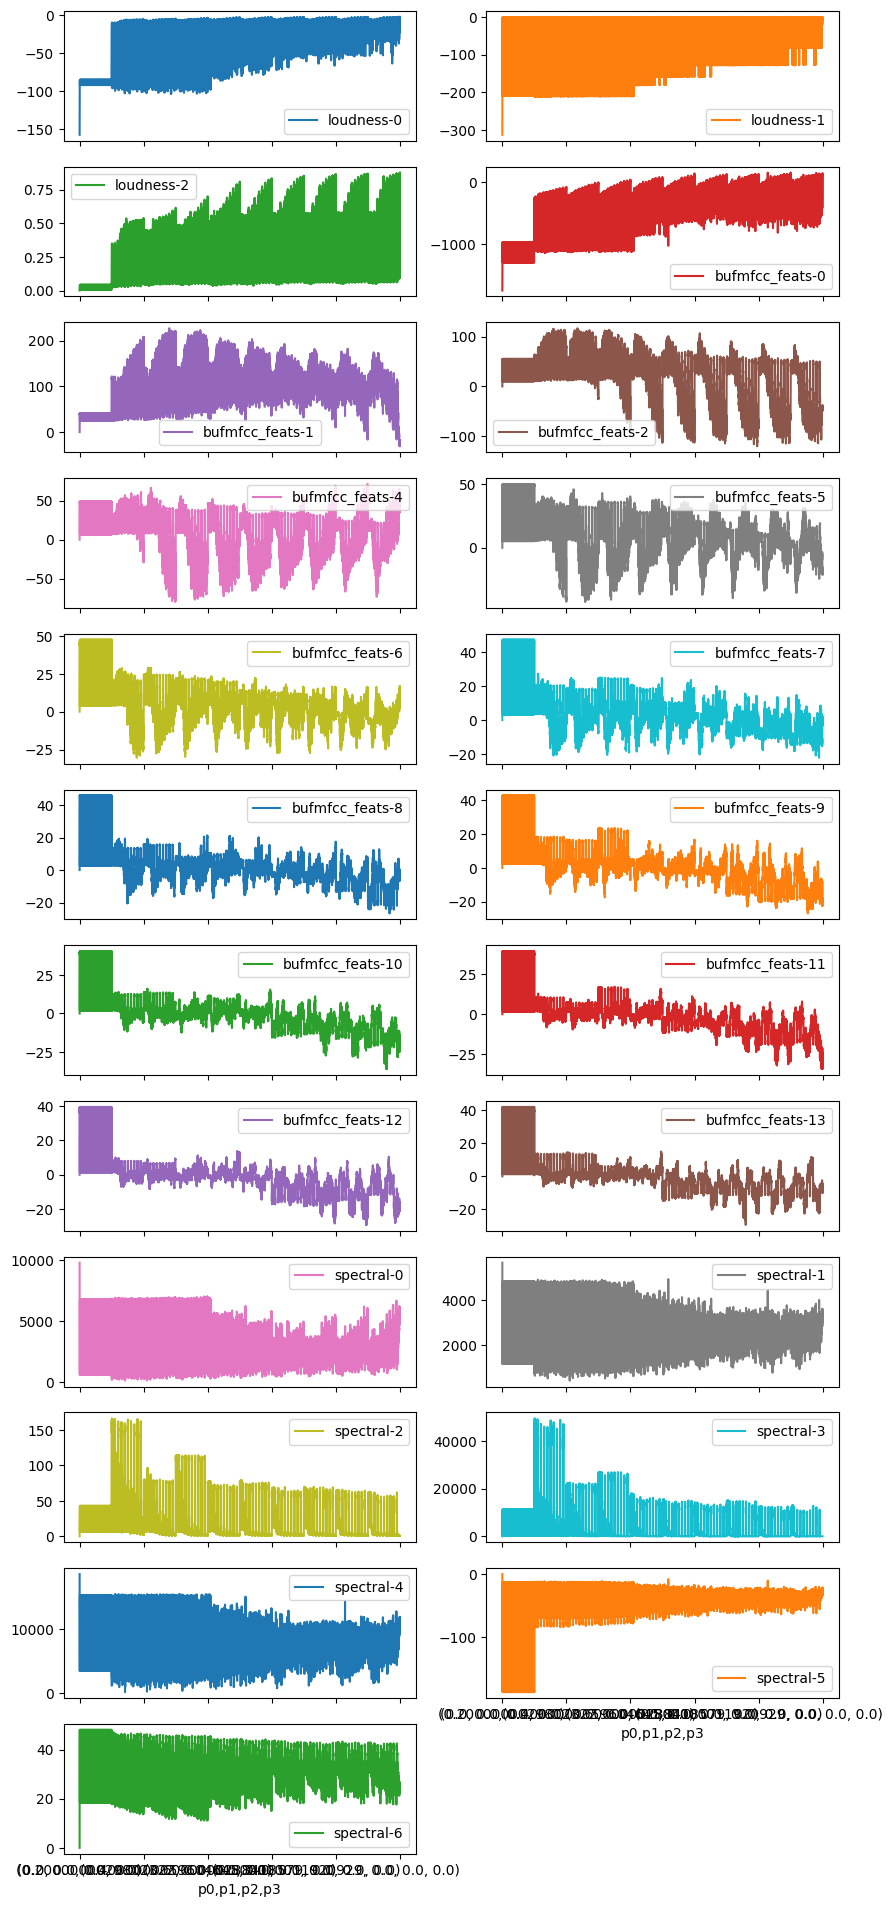

In [4]:
N_PARAMS = 4
instrument_name = '02_FM4'
feature_name = 'loudness_mfcc_spectral'
synth_space_path = f'{instrument_name}/features/{instrument_name}_{feature_name}_lookup_table.csv'
lookup_df = pd.read_csv('02_FM4/features/02_FM4_loudness_mfcc_spectral_lookup_table.csv')
param_names = [f'p{num_param}' for num_param in range(N_PARAMS)]
lookup_df = lookup_df.set_index(param_names)
lookup_df.plot(subplots=True, layout=(15,2), figsize=[10, 30])
lookup_df

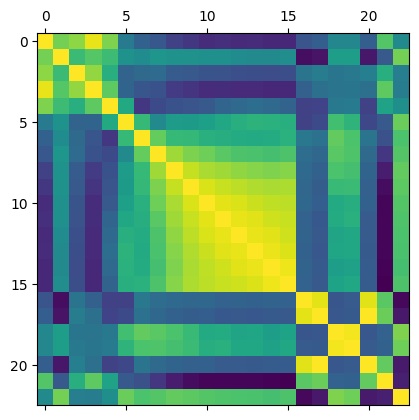

In [5]:
plt.matshow(lookup_df.corr())
plt.show()

(9157, 23)

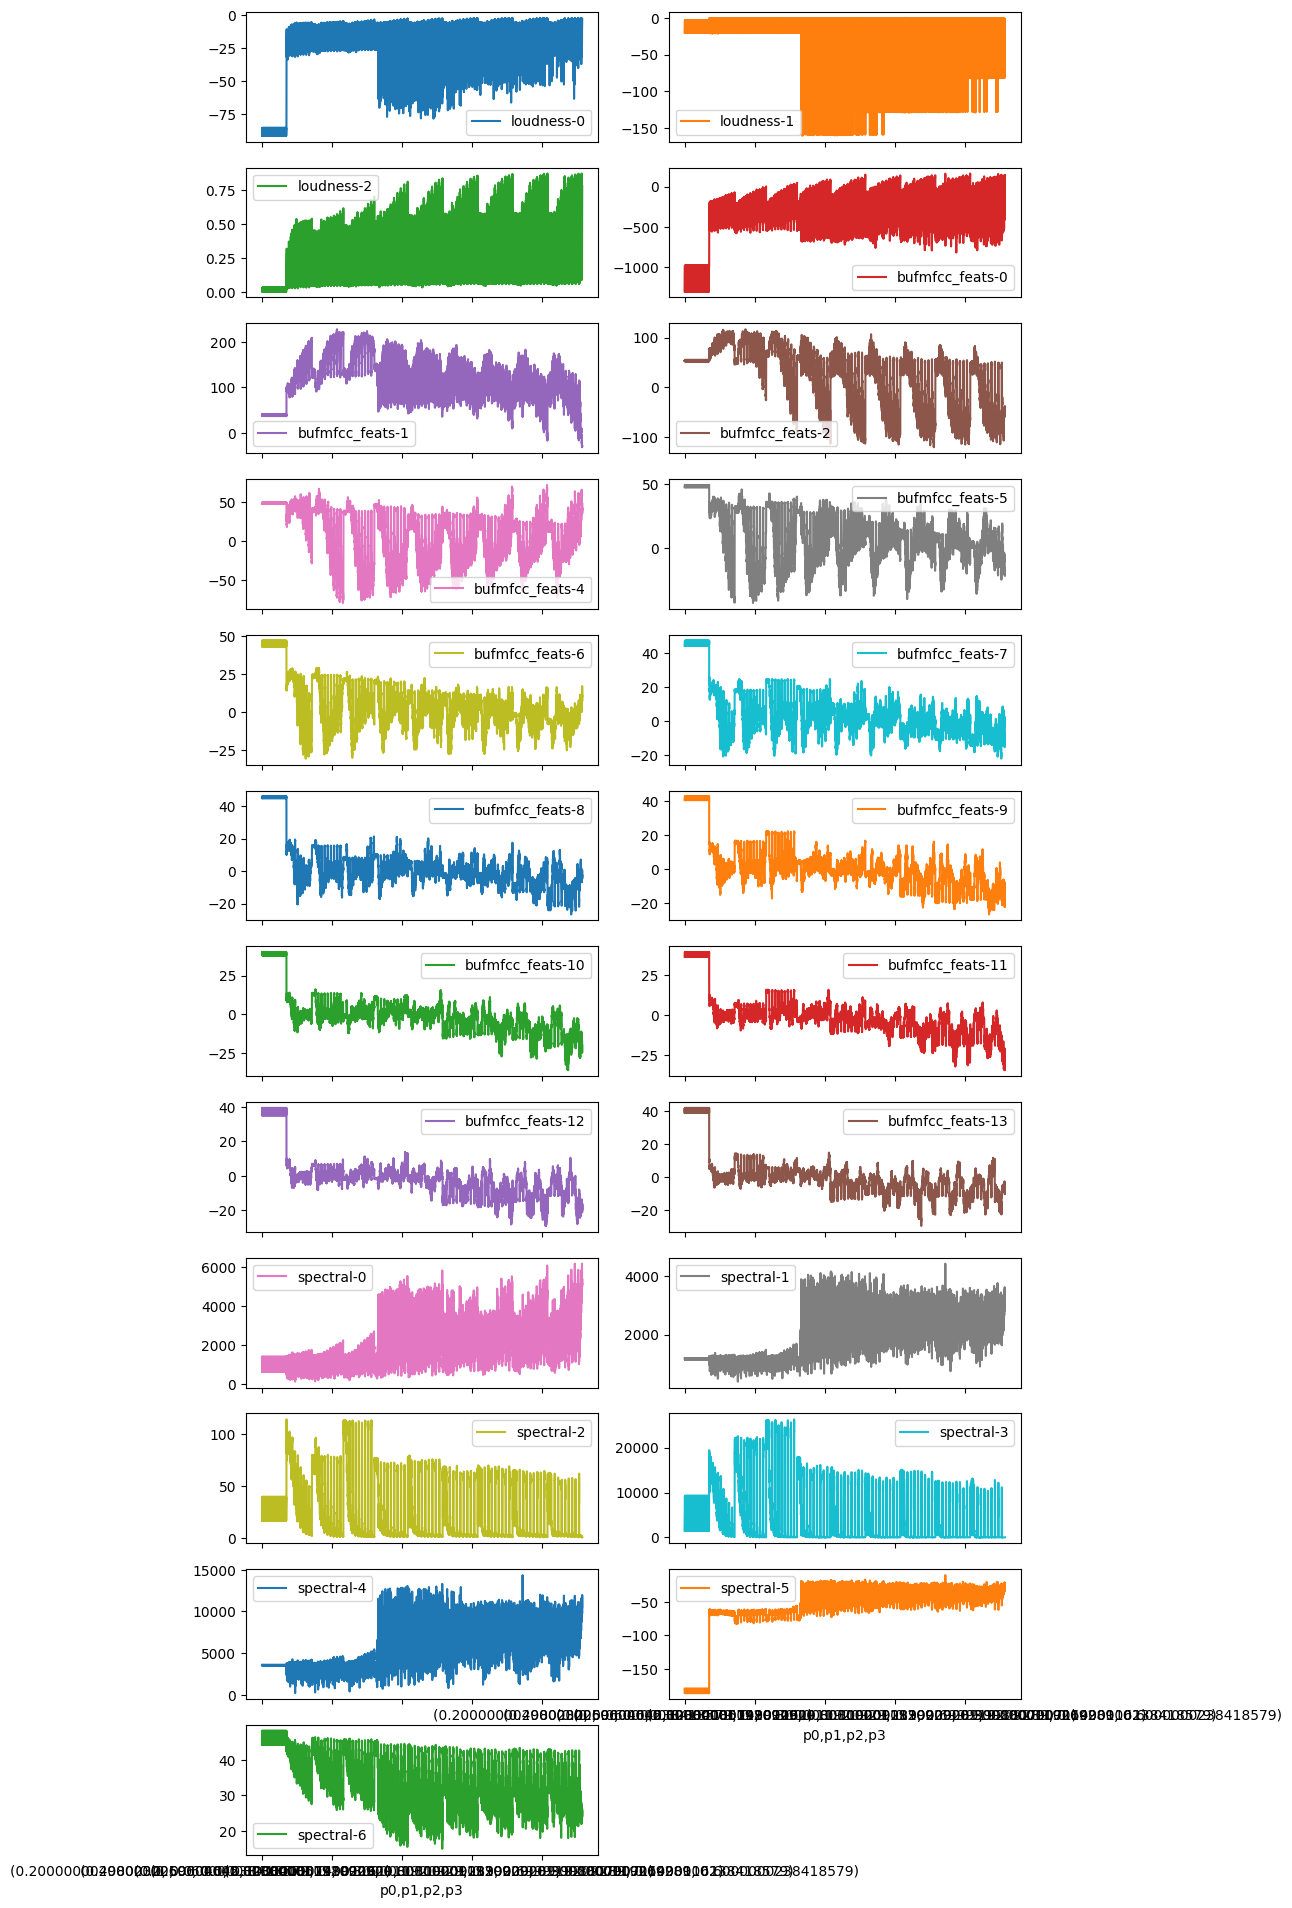

In [6]:
# remove outliers
lookup_df_no_outliers = lookup_df[(np.abs(stats.zscore(lookup_df)) < 3).all(axis=1)]
lookup_df_no_outliers.plot(subplots=True, layout=(15,2), figsize=[10, 30])
lookup_df_no_outliers.shape

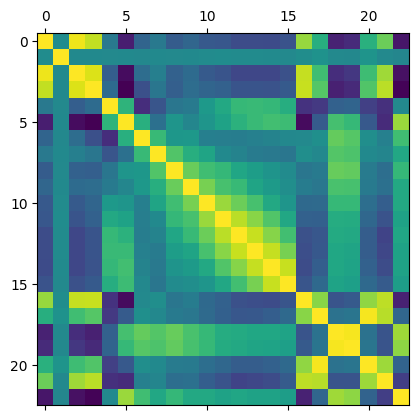

In [32]:
plt.matshow(lookup_df_no_outliers.corr())
plt.show()

loudness-0  loudness-1  loudness-2  \
p0       p1       p2                                             
0.000000 0.000000 0.000000  -15.881659    0.359158    0.334596   
                  0.033333  -46.582493    0.161390    0.084607   
                  0.066667  -46.582493    0.161390    0.084607   
                  0.100000  -46.582493    0.161390    0.084607   
                  0.133333  -46.582493    0.161390    0.084607   
...                                ...         ...         ...   
0.966667 0.966667 0.833333   -1.136936    0.590404    0.984824   
                  0.866667   -0.867850    1.017153    0.914755   
                  0.900000   -1.104205    0.074235    0.989584   
                  0.933333   -1.068483    0.656038    0.992667   
                  0.966667   -0.790739    0.956584    0.923059   

                            bufmfcc_feats-0  bufmfcc_feats-1  bufmfcc_feats-2  \
p0       p1       p2                                                            
0.000000 0.000000 0.000000      -291.697910        66.698182         0.164417   
                  0.033333      -942.248889        23.929859        53.596095   
                  0.066667      -942.248889        23.929859        53.596095   
                  0.100000      -942.248889        23.929859        53.596095   
                  0.133333      -942.248889        23.929859        53.596095   
...                                     ...              ...              ...   
0.966667 0.966667 0.833333       153.170924       -50.195985       -27.708864   
                  0.866667       143.388409       -60.738096       -36.005081   
                  0.900000       163.721390       -49.887917       -30.018402   
                  0.933333       163.284602       -50.383555       -28.926523   
                  0.966667       149.751282       -65.017462       -31.907780   

                            bufmfcc_feats-4  bufmfcc_feats-5  bufmfcc_feats-6  \
p0       p1       p2                                                            
0.000000 0.000000 0.000000        36.118009        13.179987        20.668607   
                  0.033333        45.376302        46.434539        42.631540   
                  0.066667        45.376302        46.434539        42.631540   
                  0.100000        45.376302        46.434539        42.631540   
                  0.133333        45.376302        46.434539        42.631540   
...                                     ...              ...              ...   
0.966667 0.966667 0.833333        48.321397        -8.962370        -0.993387   
                  0.866667        41.433069       -12.118815         9.548138   
                  0.900000        35.478887       -12.447097        12.048128   
                  0.933333        35.179473       -13.953353        17.393099   
                  0.966667        24.677038       -22.432949        16.388136   

                            bufmfcc_feats-7  ...  bufmfcc_feats-11  \
p0       p1       p2                         ...                     
0.000000 0.000000 0.000000        16.613494  ...         12.141916   
                  0.033333        44.588268  ...         39.766082   
                  0.066667        44.588268  ...         39.766082   
                  0.100000        44.588268  ...         39.766082   
                  0.133333        44.588268  ...         39.766082   
...                                     ...  ...               ...   
0.966667 0.966667 0.833333        -9.305346  ...        -22.977465   
                  0.866667        -4.155134  ...        -26.808037   
                  0.900000        -0.007941  ...        -21.240450   
                  0.933333         2.237857  ...        -22.764523   
                  0.966667         0.726089  ...        -24.307496   

                            bufmfcc_feats-12  bufmfcc_feats-13   spectral-0  \
p0       p1       p2                                                   

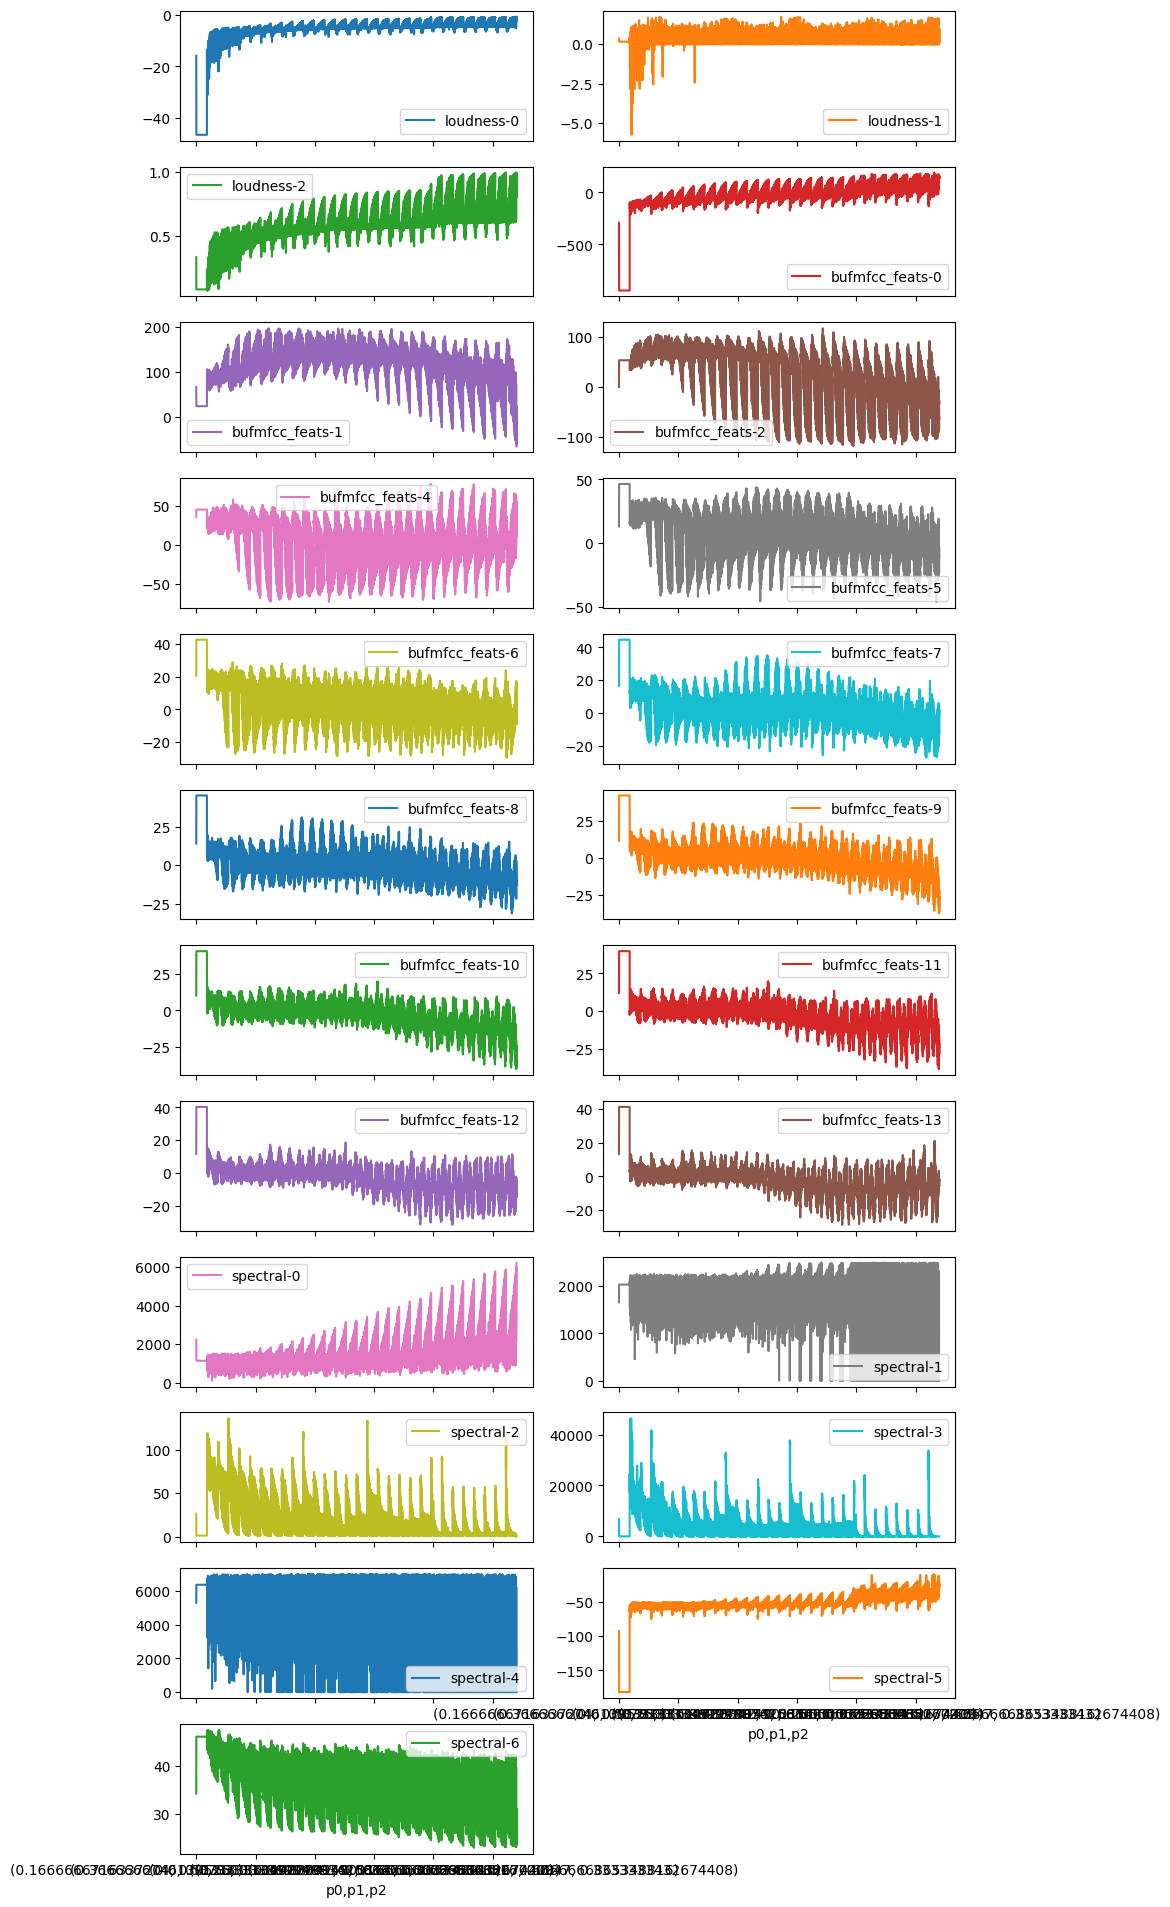

In [33]:
def filtering(features_vector):
    if features_vector.iloc[16] >= 9500:
        features_vector.iloc[16] = 0
    if features_vector.iloc[17] >= 2500:
        features_vector.iloc[17] = 0
    if features_vector.iloc[20] >= 7000:
        features_vector.iloc[20] = 0
    return features_vector

lookup_df_filtered = lookup_df.copy()
lookup_df_filtered = lookup_df_filtered.apply(lambda row: filtering(row), axis=1)
lookup_df_filtered.plot(subplots=True, layout=(15,2), figsize=[10, 30])
lookup_df_filtered